# 06 — Heating Correction ML Autotuning

**Goal**: Optimize the LightGBM heating-correction model using Optuna HPO, synthetic `open_window` feature engineering, and automated feature selection.

**3-Phase optimisation pipeline:**
1. **Label Horizon Search** — test horizon ∈ {2, 3, 4, 5, 6} hours
2. **LightGBM Hyperparameter Optimization** — 100 Optuna trials over 10 parameters
3. **Feature Selection** — permutation-importance-based pruning threshold search

**Output**: Best model saved as `*_tuned.joblib` + ready-to-paste config.yaml snippet.

## 1. Setup & Data Loading

In [10]:
import json
import math
import os
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import yaml
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Paths ──────────────────────────────────────────────────────────────
# Resolve project root reliably (notebook lives at notebooks/analysis/)
_NB_DIR = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd()
ROOT = _NB_DIR
# Walk upward until we find pyproject.toml (project root marker)
for _ in range(5):
    if (ROOT / "pyproject.toml").exists():
        break
    ROOT = ROOT.parent

DATA_DIR = ROOT / "Logs_and_models"

TRAIN_DATA_PATH = DATA_DIR / "heating_training_data.csv.gz"
METADATA_PATH = DATA_DIR / "heating_correction_ml_metadata.json"
CONFIG_HA_PATH = DATA_DIR / "config_HA.txt"

print(f"Project root: {ROOT}")
print(f"Data dir:     {DATA_DIR}")

# ── Load training data ────────────────────────────────────────────────
df = pd.read_csv(TRAIN_DATA_PATH)
print(f"\nTraining data: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

# ── Load baseline metadata ────────────────────────────────────────────
with open(METADATA_PATH) as f:
    baseline_meta = json.load(f)

BASELINE_MAE = baseline_meta["val_mae"]
BASELINE_R2 = baseline_meta["val_r2"]
S_H = baseline_meta["s_h_estimated"]
HEATING_TARGET = baseline_meta["heating_target_c"]
STEPS_PER_HOUR = baseline_meta["steps_per_hour"]
BASELINE_FEATURES = baseline_meta["feature_cols"]
BASELINE_PARAMS = baseline_meta["lgb_params"]

print(f"\n=== Baseline Model ===")
print(f"  val_MAE:  {BASELINE_MAE:.4f} °C")
print(f"  val_R²:   {BASELINE_R2:.4f}")
print(f"  Features: {len(BASELINE_FEATURES)}")
print(f"  S_H:      {S_H:.4f}")
print(f"  Target:   {HEATING_TARGET} °C")
print(f"  Horizon:  {baseline_meta['label_horizon_h']}h ({baseline_meta['label_horizon_h'] * STEPS_PER_HOUR} steps)")

# ── Load HA config ────────────────────────────────────────────────────
if CONFIG_HA_PATH.exists():
    with open(CONFIG_HA_PATH) as f:
        ha_config = yaml.safe_load(f)
    print(f"\nHA config loaded: {len(ha_config)} keys")
else:
    ha_config = {}
    print("\n⚠ config_HA.txt not found — using defaults")

# ── Label statistics ──────────────────────────────────────────────────
print(f"\n=== Label Distribution ===")
print(df["label"].describe().to_string())

Project root: c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor
Data dir:     c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\Logs_and_models

Training data: 84,312 rows × 41 columns
Columns: ['indoor_temp', 'indoor_margin', 'indoor_trend_30m', 'indoor_trend_1h', 'AT', 'at_delta_indoor', 'AT_roh_1h', 'AT_roh_2h', 'AT_roh_3h', 'AT_roh_4h', 'VLT', 'RLT', 'delta_t', 'outlet_indoor_diff', 'thermal_power_kw', 'fireplace_on', 'tv_on', 'fireplace_lag_1h', 'fireplace_lag_2h', 'tv_lag_30m', 'tv_lag_1h', 'PV_Generate', 'pv_roll_1h', 'pv_roll_2h', 'pv_forecast_1h', 'pv_forecast_2h', 'pv_forecast_3h', 'pv_forecast_4h', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wind_speed', 'indoor_temp_gradient', 'living_room_temp', 'is_hp_active', 'is_weekend', 'thermal_power_rolling_1h', 'indoor_margin_rate', 'is_overshoot', 'label']

=== Baseline Model ===
  val_MAE:  0.1466 °C
  val_R²:   0.8611
  Features: 40


## 2. Exploratory Data Analysis

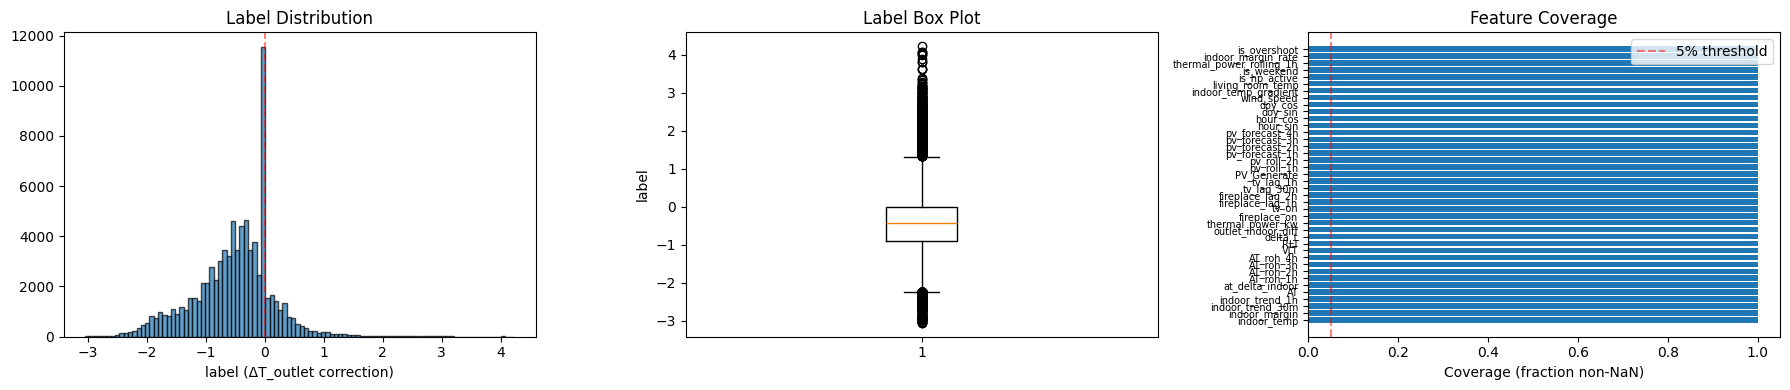

=== Top 20 Features by |correlation| with label ===
indoor_temp                 0.838828
living_room_temp            0.838828
indoor_margin               0.838828
is_overshoot                0.512373
AT                          0.290285
AT_roh_1h                   0.281975
AT_roh_2h                   0.269778
outlet_indoor_diff          0.265384
hour_sin                    0.259119
AT_roh_3h                   0.253638
at_delta_indoor             0.248456
AT_roh_4h                   0.233309
is_hp_active                0.223980
thermal_power_rolling_1h    0.219970
thermal_power_kw            0.206537
delta_t                     0.205766
VLT                         0.165326
indoor_trend_1h             0.153765
doy_cos                     0.141463
doy_sin                     0.135974


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Label distribution
axes[0].hist(df["label"].dropna(), bins=100, edgecolor="black", alpha=0.7)
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("label (ΔT_outlet correction)")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)

# Box plot
axes[1].boxplot(df["label"].dropna(), vert=True)
axes[1].set_title("Label Box Plot")
axes[1].set_ylabel("label")

# Feature coverage
feature_cols = [c for c in df.columns if c != "label"]
coverage = df[feature_cols].notna().mean().sort_values()
axes[2].barh(range(len(coverage)), coverage.values)
axes[2].set_yticks(range(len(coverage)))
axes[2].set_yticklabels(coverage.index, fontsize=7)
axes[2].set_xlabel("Coverage (fraction non-NaN)")
axes[2].set_title("Feature Coverage")
axes[2].axvline(0.05, color="red", linestyle="--", alpha=0.5, label="5% threshold")
axes[2].legend()

plt.tight_layout()
plt.show()

# Correlation with label (top 20)
corr = df[feature_cols + ["label"]].corr()["label"].drop("label").abs().sort_values(ascending=False)
print("=== Top 20 Features by |correlation| with label ===")
print(corr.head(20).to_string())

## 3. Synthetic `open_window` Feature Engineering

Detect open-window events from sudden indoor temperature drops:
- `indoor_temp` drop ≥ 0.3 °C between consecutive rows (5-min interval)
- Outdoor temp significantly lower than indoor: `(indoor_temp - AT) > 3.0 °C`
- 30-minute forward-fill to capture the recovery period after window close

In [12]:
# Synthetic open_window detection
TEMP_DROP_THRESHOLD = -0.3   # °C drop between consecutive 5-min rows
INDOOR_OUTDOOR_GAP = 3.0     # minimum indoor-outdoor delta to qualify
FORWARD_FILL_STEPS = 6       # 30 min at 5-min intervals (recovery period)

if "indoor_temp" in df.columns and "AT" in df.columns:
    temp_diff = df["indoor_temp"].diff()
    indoor_outdoor_gap = df["indoor_temp"] - df["AT"]

    # Trigger: sudden drop AND cold outside relative to inside
    raw_trigger = (temp_diff <= TEMP_DROP_THRESHOLD) & (indoor_outdoor_gap > INDOOR_OUTDOOR_GAP)

    # Forward-fill to capture recovery window after window is closed
    open_window = raw_trigger.astype(int)
    for shift in range(1, FORWARD_FILL_STEPS + 1):
        open_window = open_window | raw_trigger.shift(-shift).fillna(False).astype(int)

    df["open_window"] = open_window.astype(int)

    n_events = raw_trigger.sum()
    n_affected_rows = df["open_window"].sum()
    pct_affected = 100 * n_affected_rows / len(df)

    print(f"=== open_window Feature ===")
    print(f"  Raw trigger events: {n_events:,}")
    print(f"  Affected rows (with 30min fill): {n_affected_rows:,} ({pct_affected:.1f}%)")

    # Show a few examples
    if n_events > 0:
        trigger_indices = raw_trigger[raw_trigger].index[:3]
        for idx in trigger_indices:
            start = max(0, idx - 2)
            end = min(len(df), idx + FORWARD_FILL_STEPS + 2)
            snippet = df.iloc[start:end][["indoor_temp", "AT", "open_window"]].copy()
            snippet["temp_diff"] = df["indoor_temp"].diff().iloc[start:end]
            print(f"\n  Event at row {idx}:")
            print(snippet.to_string())
else:
    print("⚠ indoor_temp or AT columns missing — skipping open_window")

=== open_window Feature ===
  Raw trigger events: 19
  Affected rows (with 30min fill): 103 (0.1%)

  Event at row 2971:
      indoor_temp     AT  open_window  temp_diff
2969        23.68  17.30            1      -0.03
2970        23.56  17.76            1      -0.12
2971        23.22  17.95            1      -0.34
2972        23.24  17.80            0       0.02
2973        23.26  17.73            0       0.02
2974        23.29  17.60            0       0.03
2975        23.31  17.40            0       0.02
2976        23.32  17.15            0       0.01
2977        23.32  16.78            0       0.00
2978        23.32  16.58            0       0.00

  Event at row 3944:
      indoor_temp     AT  open_window  temp_diff
3942        22.84  12.50            1       0.00
3943        22.79  12.50            1      -0.05
3944        22.46  12.50            1      -0.33
3945        22.19  12.32            0      -0.27
3946        22.03  12.30            0      -0.16
3947        21.91  12.34

C:\Users\ZOJHILK\AppData\Local\Temp\ipykernel_38240\2022162314.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  open_window = open_window | raw_trigger.shift(-shift).fillna(False).astype(int)
C:\Users\ZOJHILK\AppData\Local\Temp\ipykernel_38240\2022162314.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  open_window = open_window | raw_trigger.shift(-shift).fillna(False).astype(int)
C:\Users\ZOJHILK\AppData\Local\Temp\ipykernel_38240\2022162314.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will c

## 4. Temporal Split & Evaluation Harness

- Last 25% = held-out test set (never touched by Optuna)
- First 75% = Optuna search pool with `TimeSeriesSplit(n_splits=5)` expanding windows

In [13]:
# ── Build feature column list (all available + open_window) ────────────
ALL_FEATURE_COLS = [c for c in df.columns if c != "label"]
print(f"Total available features: {len(ALL_FEATURE_COLS)}")

# ── Temporal split: 75% fit pool / 25% holdout ───────────────────────
HOLDOUT_FRAC = 0.25
n_holdout = max(1, int(len(df) * HOLDOUT_FRAC))
df_pool = df.iloc[:-n_holdout].copy().reset_index(drop=True)
df_holdout = df.iloc[-n_holdout:].copy().reset_index(drop=True)

print(f"Fit pool:  {len(df_pool):,} rows")
print(f"Holdout:   {len(df_holdout):,} rows")

# ── CV splitter ───────────────────────────────────────────────────────
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)


def compute_label(df_sub, horizon_h, s_h=S_H, target=HEATING_TARGET, sph=STEPS_PER_HOUR):
    """Re-derive label from indoor_temp for a given horizon."""
    shift_steps = horizon_h * sph
    future_indoor = df_sub["indoor_temp"].shift(-shift_steps)
    raw_label = -(future_indoor - target) / s_h

    # Trivial-margin mask (same as production pipeline)
    if "indoor_margin" in df_sub.columns:
        trivial = df_sub["indoor_margin"].abs() <= 0.05
        raw_label = raw_label.where(~trivial, other=0.0)

    return raw_label.clip(-5.0, 5.0)


def cv_evaluate(params, feature_cols, data, label_col="label"):
    """Run TimeSeriesSplit CV and return mean MAE and R²."""
    X = data[feature_cols].values.astype(np.float32)
    y = data[label_col].values

    mae_scores = []
    r2_scores = []

    for train_idx, val_idx in tscv.split(X):
        X_tr, X_vl = X[train_idx], X[val_idx]
        y_tr, y_vl = y[train_idx], y[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_vl, y_vl)],
            callbacks=[
                lgb.early_stopping(30, verbose=False),
                lgb.log_evaluation(0),  # silent
            ],
        )
        y_pred = model.predict(X_vl)
        mae_scores.append(mean_absolute_error(y_vl, y_pred))
        r2_scores.append(r2_score(y_vl, y_pred))

    return {
        "cv_mae": np.mean(mae_scores),
        "cv_mae_std": np.std(mae_scores),
        "cv_r2": np.mean(r2_scores),
        "cv_r2_std": np.std(r2_scores),
        "fold_maes": mae_scores,
        "fold_r2s": r2_scores,
    }


def holdout_evaluate(params, feature_cols, train_data, holdout_data, label_col="label"):
    """Train on full pool, evaluate on holdout."""
    X_tr = train_data[feature_cols].values.astype(np.float32)
    y_tr = train_data[label_col].values
    X_ho = holdout_data[feature_cols].values.astype(np.float32)
    y_ho = holdout_data[label_col].values

    model = lgb.LGBMRegressor(**params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_ho)

    return {
        "holdout_mae": mean_absolute_error(y_ho, y_pred),
        "holdout_r2": r2_score(y_ho, y_pred),
        "holdout_rmse": np.sqrt(mean_squared_error(y_ho, y_pred)),
        "holdout_max_err": np.max(np.abs(y_ho - y_pred)),
        "model": model,
        "y_pred": y_pred,
        "y_true": y_ho,
    }

print(f"CV strategy: TimeSeriesSplit({N_SPLITS} folds) on fit pool + final holdout")

Total available features: 41
Fit pool:  63,234 rows
Holdout:   21,078 rows
CV strategy: TimeSeriesSplit(5 folds) on fit pool + final holdout


## 5. Phase 1 — Label Horizon Search

Test `label_horizon_h ∈ {2, 3, 4, 5, 6}` hours. Re-derive the label from `indoor_temp` for each horizon using the production formula, then evaluate with default LightGBM hyperparameters.

In [14]:
# HORIZONS = [2, 3, 4, 5, 6]
HORIZONS = [4]

# Default params for horizon search (production defaults)
default_params = {
    "objective": "regression_l1",
    "metric": "mae",
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 6,
    "num_leaves": 31,
    "min_child_samples": 20,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

horizon_results = []

for h in HORIZONS:
    print(f"\n--- Horizon = {h}h ---")
    # Re-derive label for this horizon on the full dataset
    new_label = compute_label(df, h)

    # Build temporary dataset with new label
    df_temp = df.copy()
    df_temp["label_h"] = new_label
    df_temp = df_temp.dropna(subset=ALL_FEATURE_COLS + ["label_h"])

    # Re-split (same proportions)
    n_ho = max(1, int(len(df_temp) * HOLDOUT_FRAC))
    pool_h = df_temp.iloc[:-n_ho].reset_index(drop=True)

    cv_res = cv_evaluate(default_params, ALL_FEATURE_COLS, pool_h, label_col="label_h")
    print(f"  CV MAE: {cv_res['cv_mae']:.4f} ± {cv_res['cv_mae_std']:.4f}")
    print(f"  CV R²:  {cv_res['cv_r2']:.4f} ± {cv_res['cv_r2_std']:.4f}")
    print(f"  Rows:   {len(pool_h):,} (dropped {len(df) - len(df_temp):,} NaN tail rows)")

    horizon_results.append({
        "horizon_h": h,
        "cv_mae": cv_res["cv_mae"],
        "cv_mae_std": cv_res["cv_mae_std"],
        "cv_r2": cv_res["cv_r2"],
        "cv_r2_std": cv_res["cv_r2_std"],
        "n_rows": len(pool_h),
    })

# Results table
hr_df = pd.DataFrame(horizon_results)
print("\n=== Horizon Search Results ===")
print(hr_df.to_string(index=False))

# Select best horizon
best_horizon = hr_df.loc[hr_df["cv_mae"].idxmin(), "horizon_h"]
best_horizon = int(best_horizon)
print(f"\n✅ Best horizon: {best_horizon}h (CV MAE = {hr_df.loc[hr_df['cv_mae'].idxmin(), 'cv_mae']:.4f})")

# Re-derive label with best horizon and update df_pool / df_holdout
best_label = compute_label(df, best_horizon)
df["label"] = best_label
df_clean = df.dropna(subset=ALL_FEATURE_COLS + ["label"]).reset_index(drop=True)
n_holdout = max(1, int(len(df_clean) * HOLDOUT_FRAC))
df_pool = df_clean.iloc[:-n_holdout].reset_index(drop=True)
df_holdout = df_clean.iloc[-n_holdout:].reset_index(drop=True)
print(f"Updated splits: pool={len(df_pool):,}, holdout={len(df_holdout):,}")


--- Horizon = 4h ---
  CV MAE: 0.2109 ± 0.1472
  CV R²:  0.7567 ± 0.1087
  Rows:   63,216 (dropped 24 NaN tail rows)

=== Horizon Search Results ===
 horizon_h   cv_mae  cv_mae_std    cv_r2  cv_r2_std  n_rows
         4 0.210853    0.147179 0.756672   0.108727   63216

✅ Best horizon: 4h (CV MAE = 0.2109)
Updated splits: pool=63,216, holdout=21,072


## 6. Phase 2 — LightGBM Hyperparameter Optimization (100 Optuna trials)

Search space: `learning_rate`, `max_depth`, `num_leaves`, `min_child_samples`, `n_estimators`, `reg_alpha`, `reg_lambda`, `subsample`, `colsample_bytree`, `min_split_gain`.

In [15]:
N_TRIALS = 100

def optuna_objective(trial):
    """Optuna objective: minimize mean CV MAE."""
    params = {
        "objective": "regression_l1",
        "metric": "mae",
        "verbosity": -1,
        "n_jobs": -1,
        "random_state": 42,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_split_gain": trial.suggest_float("min_split_gain", 1e-4, 1.0, log=True),
    }

    cv_res = cv_evaluate(params, ALL_FEATURE_COLS, df_pool)
    return cv_res["cv_mae"]


print(f"Starting Optuna HPO: {N_TRIALS} trials, {N_SPLITS}-fold expanding-window CV")
print(f"Features: {len(ALL_FEATURE_COLS)}, Pool size: {len(df_pool):,}")

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
)
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=True)

# ── Results ───────────────────────────────────────────────────────────
best_trial = study.best_trial
print(f"\n=== Best Trial #{best_trial.number} ===")
print(f"  CV MAE: {best_trial.value:.4f}")
print(f"\n  Best Parameters:")
for k, v in best_trial.params.items():
    if isinstance(v, float):
        print(f"    {k}: {v:.6f}")
    else:
        print(f"    {k}: {v}")

# Build full param dict for best trial
best_params = {
    "objective": "regression_l1",
    "metric": "mae",
    "verbosity": -1,
    "n_jobs": -1,
    "random_state": 42,
    **best_trial.params,
}

# Quick CV validation of best params
cv_best = cv_evaluate(best_params, ALL_FEATURE_COLS, df_pool)
print(f"\n  Validated CV MAE: {cv_best['cv_mae']:.4f} ± {cv_best['cv_mae_std']:.4f}")
print(f"  Validated CV R²:  {cv_best['cv_r2']:.4f} ± {cv_best['cv_r2_std']:.4f}")

Starting Optuna HPO: 100 trials, 5-fold expanding-window CV
Features: 41, Pool size: 63,216


  0%|          | 0/100 [00:00<?, ?it/s]


=== Best Trial #81 ===
  CV MAE: 0.1644

  Best Parameters:
    learning_rate: 0.209929
    max_depth: 3
    num_leaves: 18
    min_child_samples: 94
    n_estimators: 500
    reg_alpha: 0.048957
    reg_lambda: 0.006946
    subsample: 0.648605
    colsample_bytree: 0.629104
    min_split_gain: 0.621935

  Validated CV MAE: 0.1644 ± 0.0521
  Validated CV R²:  0.8022 ± 0.0267


## 7. Phase 3 — Feature Selection (Permutation Importance)

Train with best HPO params, compute permutation importance, then search for the optimal pruning threshold via Optuna (20 trials). Accept pruning only if MAE regression ≤ 0.5%.

In [16]:
# ── Compute permutation importance across CV folds ────────────────────
print("Computing permutation importance across CV folds...")

perm_importances = {col: [] for col in ALL_FEATURE_COLS}
X_pool = df_pool[ALL_FEATURE_COLS].values.astype(np.float32)
y_pool = df_pool["label"].values

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_pool)):
    X_tr, X_vl = X_pool[train_idx], X_pool[val_idx]
    y_tr, y_vl = y_pool[train_idx], y_pool[val_idx]

    model_pi = lgb.LGBMRegressor(**best_params)
    model_pi.fit(
        X_tr, y_tr,
        eval_set=[(X_vl, y_vl)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)],
    )
    perm_result = permutation_importance(
        model_pi, X_vl, y_vl,
        n_repeats=10, random_state=42, n_jobs=1,
        scoring="neg_mean_absolute_error",
    )
    for i, col in enumerate(ALL_FEATURE_COLS):
        perm_importances[col].append(perm_result.importances_mean[i])

# Average PI across folds
mean_pi = {col: np.mean(vals) for col, vals in perm_importances.items()}
pi_sorted = sorted(mean_pi.items(), key=lambda x: x[1], reverse=True)

print("\n=== Mean Permutation Importance (across 5 folds) ===")
for fname, imp in pi_sorted:
    marker = "  " if imp > 0 else "⚠️"
    print(f"  {marker} {fname:30s}  PI={imp:.5f}")

# ── Optuna threshold search ──────────────────────────────────────────
PRUNE_TRIALS = 20

# Get unpruned baseline CV MAE with best params
unpruned_cv = cv_evaluate(best_params, ALL_FEATURE_COLS, df_pool)
unpruned_mae = unpruned_cv["cv_mae"]
print(f"\nUnpruned CV MAE (best params): {unpruned_mae:.4f}")


def prune_objective(trial):
    """Search for best pruning threshold."""
    threshold = trial.suggest_float("pi_threshold", 0.0, 0.005)

    # Keep features with PI > threshold
    kept = [fname for fname, imp in mean_pi.items() if imp > threshold]
    if len(kept) < 5:
        return float("inf")  # too aggressive

    res = cv_evaluate(best_params, kept, df_pool)
    mae_regression_pct = (res["cv_mae"] - unpruned_mae) / unpruned_mae * 100
    # Penalize if regression > 0.5%
    if mae_regression_pct > 0.5:
        return float("inf")
    return res["cv_mae"]


print(f"\nStarting pruning threshold search ({PRUNE_TRIALS} trials)...")
prune_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
prune_study.optimize(prune_objective, n_trials=PRUNE_TRIALS, show_progress_bar=True)

best_threshold = prune_study.best_trial.params["pi_threshold"]
FINAL_FEATURES = [fname for fname, imp in mean_pi.items() if imp > best_threshold]
dropped = [fname for fname, imp in mean_pi.items() if imp <= best_threshold]

print(f"\n=== Feature Selection Results ===")
print(f"  Best threshold: {best_threshold:.5f}")
print(f"  Features kept:  {len(FINAL_FEATURES)} / {len(ALL_FEATURE_COLS)}")
print(f"  Dropped ({len(dropped)}): {dropped}")

# Validate pruned model
pruned_cv = cv_evaluate(best_params, FINAL_FEATURES, df_pool)
mae_diff_pct = (pruned_cv["cv_mae"] - unpruned_mae) / unpruned_mae * 100
print(f"\n  Pruned CV MAE:   {pruned_cv['cv_mae']:.4f} (Δ = {mae_diff_pct:+.2f}%)")
print(f"  Pruned CV R²:    {pruned_cv['cv_r2']:.4f}")
print(f"  Unpruned CV MAE: {unpruned_mae:.4f}")

# Accept pruning only if no significant regression
if mae_diff_pct > 0.5:
    print(f"\n⚠ Pruning rejected (MAE regression {mae_diff_pct:.2f}% > 0.5%) — keeping all features")
    FINAL_FEATURES = ALL_FEATURE_COLS
    best_threshold = 0.0
else:
    print(f"\n✅ Pruning accepted (MAE regression {mae_diff_pct:.2f}% ≤ 0.5%)")

Computing permutation importance across CV folds...

=== Mean Permutation Importance (across 5 folds) ===
     indoor_temp                     PI=0.20567
     indoor_margin                   PI=0.08394
     living_room_temp                PI=0.01850
     pv_forecast_4h                  PI=0.01783
     hour_cos                        PI=0.00775
     pv_forecast_3h                  PI=0.00524
     PV_Generate                     PI=0.00512
     RLT                             PI=0.00411
     pv_forecast_1h                  PI=0.00305
     AT_roh_2h                       PI=0.00267
     indoor_trend_1h                 PI=0.00262
     thermal_power_rolling_1h        PI=0.00254
     delta_t                         PI=0.00163
     AT_roh_3h                       PI=0.00140
     fireplace_on                    PI=0.00103
     outlet_indoor_diff              PI=0.00099
     VLT                             PI=0.00099
     is_overshoot                    PI=0.00099
     AT_roh_1h                

  0%|          | 0/20 [00:00<?, ?it/s]


=== Feature Selection Results ===
  Best threshold: 0.00115
  Features kept:  14 / 41
  Dropped (27): ['indoor_trend_30m', 'AT', 'at_delta_indoor', 'AT_roh_1h', 'AT_roh_4h', 'VLT', 'outlet_indoor_diff', 'thermal_power_kw', 'fireplace_on', 'tv_on', 'fireplace_lag_1h', 'fireplace_lag_2h', 'tv_lag_30m', 'tv_lag_1h', 'pv_roll_1h', 'pv_roll_2h', 'pv_forecast_2h', 'hour_sin', 'doy_sin', 'doy_cos', 'wind_speed', 'indoor_temp_gradient', 'is_hp_active', 'is_weekend', 'indoor_margin_rate', 'is_overshoot', 'open_window']

  Pruned CV MAE:   0.1615 (Δ = -1.77%)
  Pruned CV R²:    0.8043
  Unpruned CV MAE: 0.1644

✅ Pruning accepted (MAE regression -1.77% ≤ 0.5%)


## 8. Final Evaluation on Holdout

Train the final model with best {horizon, hyperparams, features} on the full 75% fit pool, then evaluate on the 25% holdout. Save the tuned model files.

Training final model: 14 features, horizon=4h

=== Holdout Results ===
  MAE:      0.1574 °C
  R²:       0.8515
  RMSE:     0.2580 °C
  Max err:  2.7549 °C

=== Baseline vs Autotuned ===
     Metric Baseline (production) Autotuned
   MAE (°C)                0.1466    0.1574
         R²                0.8611    0.8515
   Features                    40        14
Horizon (h)                     4         4


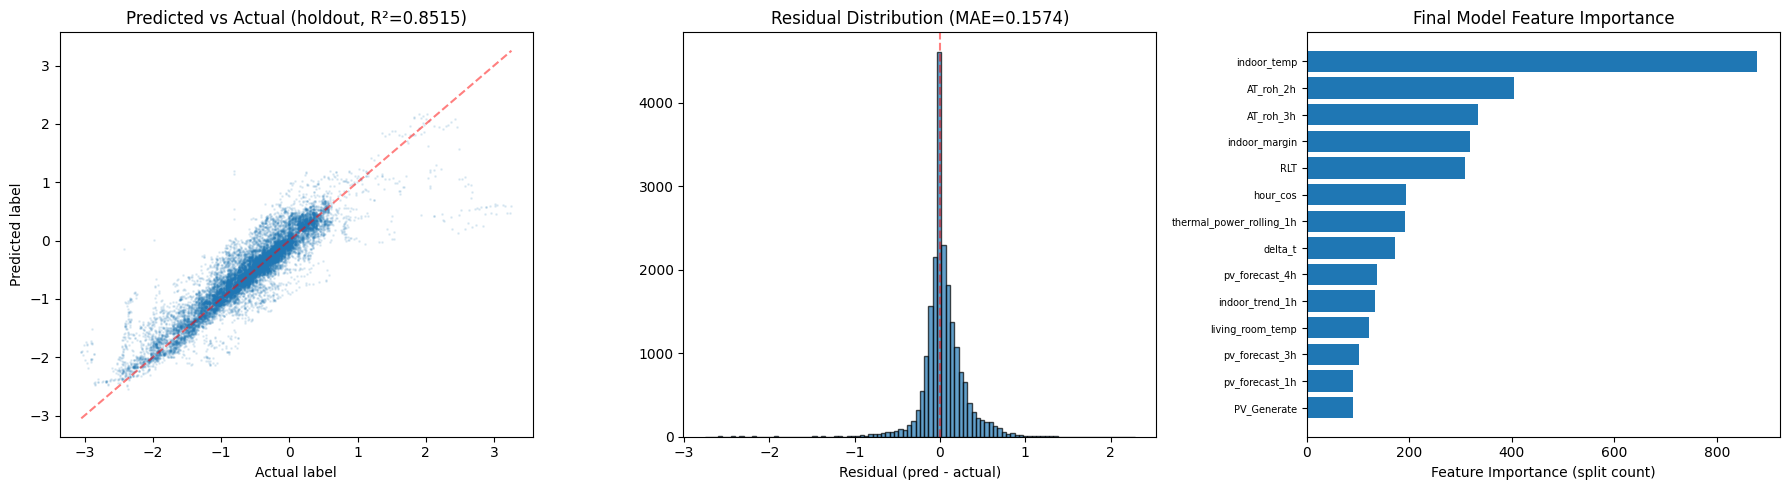


✅ Tuned model saved: c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\Logs_and_models\heating_correction_ml_model_tuned.joblib
✅ Tuned metadata saved: c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\Logs_and_models\heating_correction_ml_metadata_tuned.json


In [17]:
# ── Train final model on full pool ─────────────────────────────────────
print(f"Training final model: {len(FINAL_FEATURES)} features, horizon={best_horizon}h")
final_result = holdout_evaluate(best_params, FINAL_FEATURES, df_pool, df_holdout)

print(f"\n=== Holdout Results ===")
print(f"  MAE:      {final_result['holdout_mae']:.4f} °C")
print(f"  R²:       {final_result['holdout_r2']:.4f}")
print(f"  RMSE:     {final_result['holdout_rmse']:.4f} °C")
print(f"  Max err:  {final_result['holdout_max_err']:.4f} °C")

# ── Comparison table ──────────────────────────────────────────────────
comparison = pd.DataFrame({
    "Metric": ["MAE (°C)", "R²", "Features", "Horizon (h)"],
    "Baseline (production)": [
        f"{BASELINE_MAE:.4f}",
        f"{BASELINE_R2:.4f}",
        str(len(BASELINE_FEATURES)),
        str(baseline_meta["label_horizon_h"]),
    ],
    "Autotuned": [
        f"{final_result['holdout_mae']:.4f}",
        f"{final_result['holdout_r2']:.4f}",
        str(len(FINAL_FEATURES)),
        str(best_horizon),
    ],
})
print("\n=== Baseline vs Autotuned ===")
print(comparison.to_string(index=False))

# ── Diagnostic plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs actual
y_true = final_result["y_true"]
y_pred = final_result["y_pred"]
axes[0].scatter(y_true, y_pred, alpha=0.1, s=1)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", alpha=0.5)
axes[0].set_xlabel("Actual label")
axes[0].set_ylabel("Predicted label")
axes[0].set_title(f"Predicted vs Actual (holdout, R²={final_result['holdout_r2']:.4f})")

# Residual distribution
residuals = y_pred - y_true
axes[1].hist(residuals, bins=100, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Residual (pred - actual)")
axes[1].set_title(f"Residual Distribution (MAE={final_result['holdout_mae']:.4f})")

# Feature importance (final model)
model = final_result["model"]
importances = model.feature_importances_
feat_imp = sorted(zip(FINAL_FEATURES, importances), key=lambda x: x[1])
axes[2].barh([f[0] for f in feat_imp], [f[1] for f in feat_imp])
axes[2].set_xlabel("Feature Importance (split count)")
axes[2].set_title("Final Model Feature Importance")
axes[2].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

# ── Save tuned model ─────────────────────────────────────────────────
from datetime import datetime, timezone

model_out = DATA_DIR / "heating_correction_ml_model_tuned.joblib"
meta_out = DATA_DIR / "heating_correction_ml_metadata_tuned.json"

joblib.dump(model, model_out)
print(f"\n✅ Tuned model saved: {model_out}")

# Build metadata matching production format
tuned_metadata = {
    "trained_at": datetime.now(tz=timezone.utc).isoformat(),
    "feature_cols": FINAL_FEATURES,
    "n_features": len(FINAL_FEATURES),
    "val_mae": final_result["holdout_mae"],
    "val_r2": final_result["holdout_r2"],
    "n_train": int(len(df_pool)),
    "n_val": int(len(df_holdout)),
    "label_horizon_h": best_horizon,
    "steps_per_hour": STEPS_PER_HOUR,
    "cold_threshold_c": baseline_meta["cold_threshold_c"],
    "heating_target_c": HEATING_TARGET,
    "s_h_estimated": S_H,
    "eta": baseline_meta["eta"],
    "u_loss": baseline_meta["u_loss"],
    "tau_room": baseline_meta["tau_room"],
    "lookback_hours": baseline_meta["lookback_hours"],
    "at_forecast_hours": baseline_meta.get("at_forecast_hours", [1, 2, 3, 4]),
    "pv_forecast_hours": baseline_meta.get("pv_forecast_hours", [1, 2, 3, 4]),
    "fireplace_lag_hours": baseline_meta.get("fireplace_lag_hours", [1.0, 2.0]),
    "tv_lag_hours": baseline_meta.get("tv_lag_hours", [0.5, 1.0]),
    "lgb_params": best_params,
    "feature_importances": {
        fname: int(imp) for fname, imp in zip(FINAL_FEATURES, importances)
    },
    "autotuning": {
        "optuna_n_trials": N_TRIALS,
        "prune_pi_threshold": best_threshold,
        "cv_n_splits": N_SPLITS,
        "horizons_tested": HORIZONS,
        "best_horizon": best_horizon,
        "baseline_mae": BASELINE_MAE,
        "baseline_r2": BASELINE_R2,
        "holdout_rmse": final_result["holdout_rmse"],
        "holdout_max_err": final_result["holdout_max_err"],
        "features_dropped": dropped if 'dropped' in dir() else [],
        "has_open_window": "open_window" in FINAL_FEATURES,
    },
}

with open(meta_out, "w", encoding="utf-8") as fh:
    json.dump(tuned_metadata, fh, indent=2, default=str)
print(f"✅ Tuned metadata saved: {meta_out}")

## 9. Config Output & Recommendations

Ready-to-paste YAML block for `config.yaml` / `config_HA.txt`. To deploy the tuned model, copy `*_tuned.joblib` → `heating_correction_ml_model.joblib`.

In [18]:
# ── Generate config.yaml snippet ──────────────────────────────────────
bp = best_params
config_snippet = f"""# ── Autotuned Heating ML Parameters (generated {datetime.now().strftime('%Y-%m-%d %H:%M')}) ──
# Paste into your HA addon config (config.yaml / config_HA.txt)

heating_ml_label_horizon_h: {best_horizon}
heating_ml_reg_alpha: {bp.get('reg_alpha', 0.1):.6f}
heating_ml_reg_lambda: {bp.get('reg_lambda', 1.0):.6f}
heating_ml_prune_pi_threshold: {best_threshold:.5f}
heating_ml_feature_pruning_enabled: true
heating_ml_optuna_enabled: true
heating_ml_optuna_n_trials: {N_TRIALS}
heating_ml_cv_enabled: true
heating_ml_cv_n_splits: {N_SPLITS}
"""

print(config_snippet)

# ── Delta summary ─────────────────────────────────────────────────────
mae_improvement = (BASELINE_MAE - final_result["holdout_mae"]) / BASELINE_MAE * 100
r2_improvement = (final_result["holdout_r2"] - BASELINE_R2) / BASELINE_R2 * 100

print("=" * 60)
print("AUTOTUNING SUMMARY")
print("=" * 60)
print(f"  MAE:  {BASELINE_MAE:.4f} → {final_result['holdout_mae']:.4f} ({mae_improvement:+.2f}%)")
print(f"  R²:   {BASELINE_R2:.4f} → {final_result['holdout_r2']:.4f} ({r2_improvement:+.2f}%)")
print(f"  Features: {len(BASELINE_FEATURES)} → {len(FINAL_FEATURES)}")
print(f"  Horizon:  {baseline_meta['label_horizon_h']}h → {best_horizon}h")
if "open_window" in FINAL_FEATURES:
    print(f"  ✅ open_window feature included in final model")
else:
    print(f"  ⚠ open_window feature was pruned (low importance)")
print("=" * 60)

print(f"\nTo deploy:")
print(f"  1. Copy the config snippet above into your HA addon config")
print(f"  2. On the Pi, replace the production model:")
print(f"     cp heating_correction_ml_model_tuned.joblib heating_correction_ml_model.joblib")
print(f"     cp heating_correction_ml_metadata_tuned.json heating_correction_ml_metadata.json")
print(f"  3. Restart the addon")

# ── Autotuned Heating ML Parameters (generated 2026-05-18 00:07) ──
# Paste into your HA addon config (config.yaml / config_HA.txt)

heating_ml_label_horizon_h: 4
heating_ml_reg_alpha: 0.048957
heating_ml_reg_lambda: 0.006946
heating_ml_prune_pi_threshold: 0.00115
heating_ml_feature_pruning_enabled: true
heating_ml_optuna_enabled: true
heating_ml_optuna_n_trials: 100
heating_ml_cv_enabled: true
heating_ml_cv_n_splits: 5

AUTOTUNING SUMMARY
  MAE:  0.1466 → 0.1574 (-7.37%)
  R²:   0.8611 → 0.8515 (-1.11%)
  Features: 40 → 14
  Horizon:  4h → 4h
  ⚠ open_window feature was pruned (low importance)

To deploy:
  1. Copy the config snippet above into your HA addon config
  2. On the Pi, replace the production model:
     cp heating_correction_ml_model_tuned.joblib heating_correction_ml_model.joblib
     cp heating_correction_ml_metadata_tuned.json heating_correction_ml_metadata.json
  3. Restart the addon
